In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [72]:
df = pd.read_csv("forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [73]:
df1=df.copy()

# 1. Làm sạch-khám phá dữ liệu

In [74]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [75]:
df.dtypes

X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

In [76]:
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
             'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}

day_map = {'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5, 'sat':6, 'sun':7}

df['month'] = df['month'].map(month_map)
df['day'] = df['day'].map(day_map)


In [77]:
import numpy as np

# Encode month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Encode day (7 ngày/tuần)
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)


# xử lý "area"

In [79]:
import numpy as np

# Log-transform biến mục tiêu
df['log_area'] = np.log(df['area'] + 1)


# Trực quan hóa dữ liệu

In [80]:


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Nếu chưa có cột log_area thì thêm vào để xử lý skewness
if 'log_area' not in df.columns:
    df['log_area'] = np.log(df['area']+ 1)


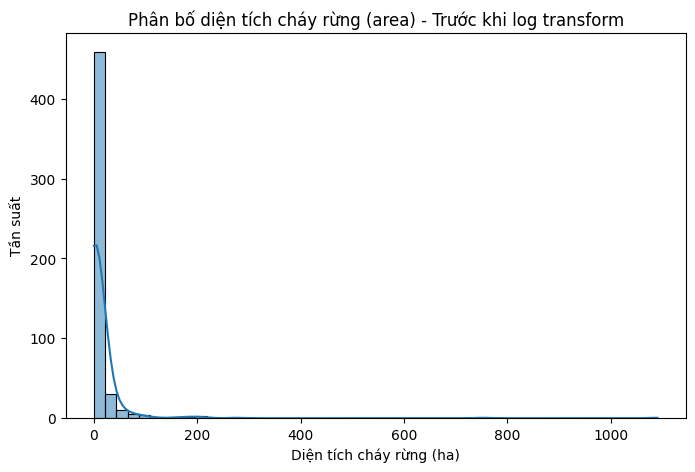

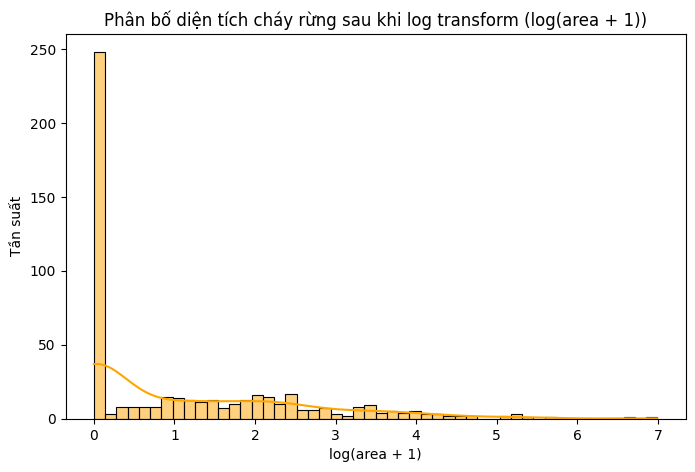

In [81]:
# --- 3.1 Phân bố biến mục tiêu area ---

plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=50, kde=True)
plt.title("Phân bố diện tích cháy rừng (area) - Trước khi log transform")
plt.xlabel("Diện tích cháy rừng (ha)")
plt.ylabel("Tần suất")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['log_area'], bins=50, kde=True, color='orange')
plt.title("Phân bố diện tích cháy rừng sau khi log transform (log(area + 1))")
plt.xlabel("log(area + 1)")
plt.ylabel("Tần suất")
plt.show()


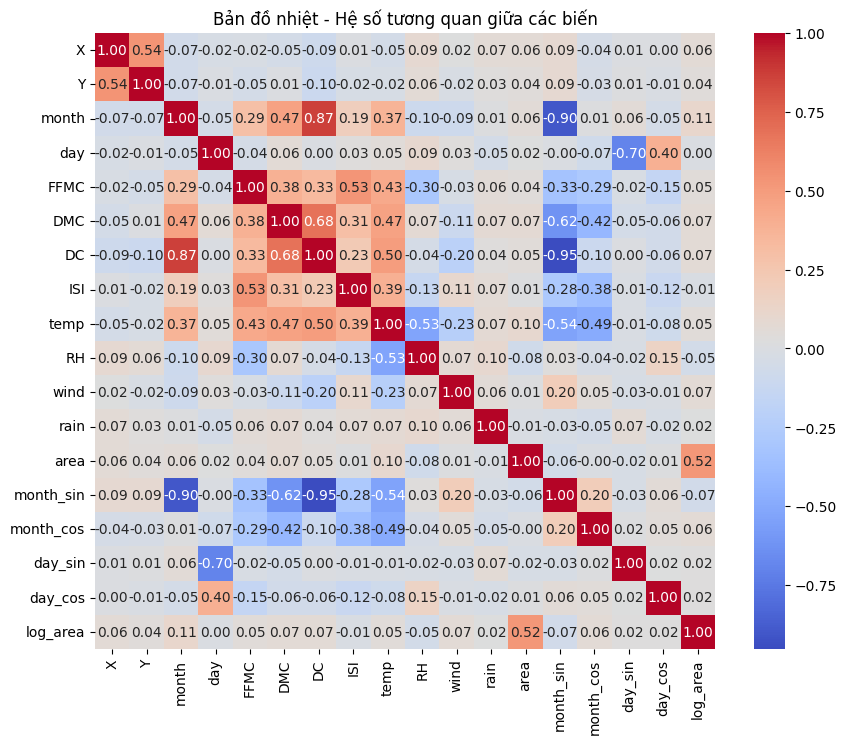

In [82]:
# --- 3.2 Bản đồ nhiệt tương quan giữa các biến ---

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Bản đồ nhiệt - Hệ số tương quan giữa các biến")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20688\48839869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='month', y='log_area', palette='Set2', estimator='mean')


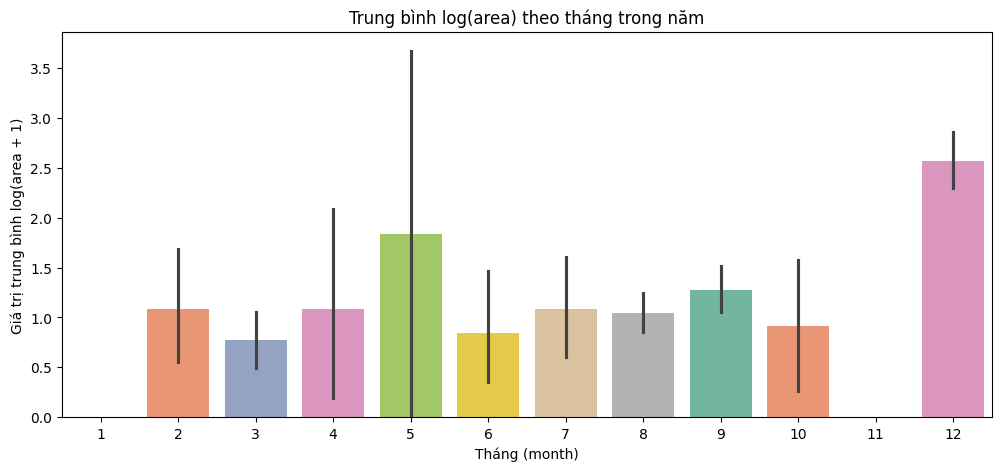

C:\Users\Admin\AppData\Local\Temp\ipykernel_20688\48839869.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day', y='log_area', palette='Set3', estimator='mean')


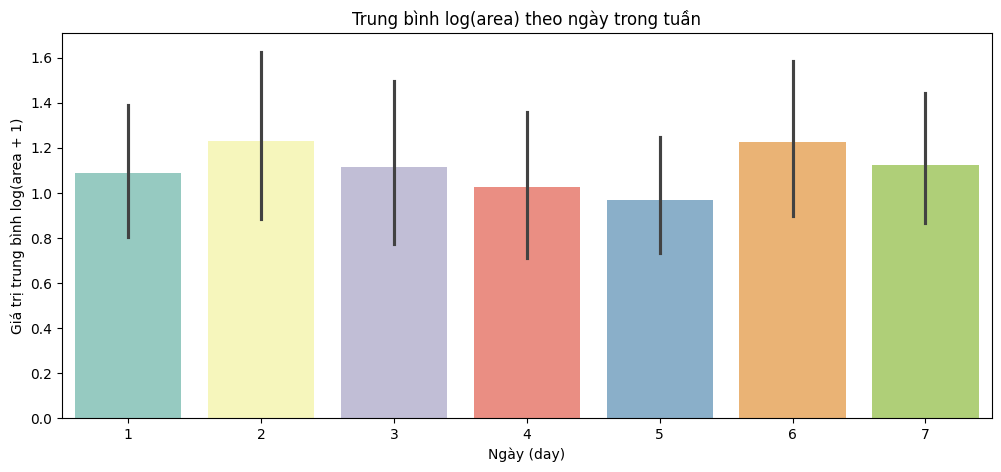

In [83]:
# --- 3.4 Phân bố diện tích cháy theo tháng và ngày ---

# Trung bình log(area) theo tháng
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='month', y='log_area', palette='Set2', estimator='mean')
plt.title("Trung bình log(area) theo tháng trong năm")
plt.xlabel("Tháng (month)")
plt.ylabel("Giá trị trung bình log(area + 1)")
plt.show()

# Trung bình log(area) theo ngày
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='day', y='log_area', palette='Set3', estimator='mean')
plt.title("Trung bình log(area) theo ngày trong tuần")
plt.xlabel("Ngày (day)")
plt.ylabel("Giá trị trung bình log(area + 1)")
plt.show()

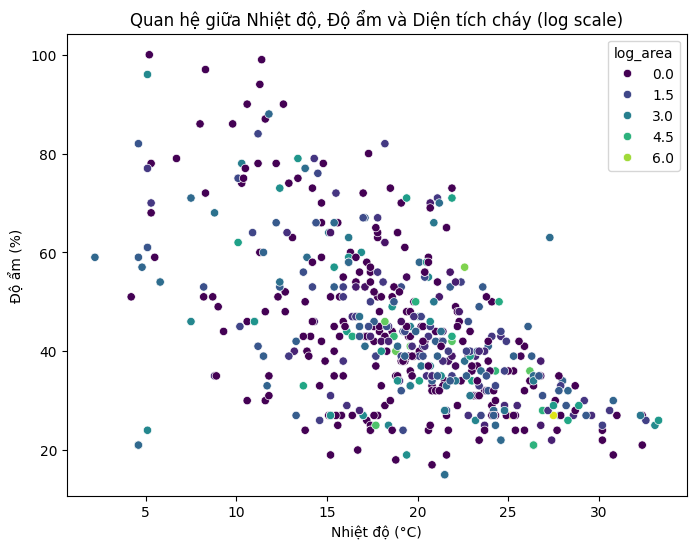

In [84]:
# --- 3.5 Ảnh hưởng của nhiệt độ & độ ẩm đến diện tích cháy ---

plt.figure(figsize=(8,6))
sns.scatterplot(x='temp', y='RH', hue='log_area', data=df, palette='viridis')
plt.title("Quan hệ giữa Nhiệt độ, Độ ẩm và Diện tích cháy (log scale)")
plt.xlabel("Nhiệt độ (°C)")
plt.ylabel("Độ ẩm (%)")
plt.show()


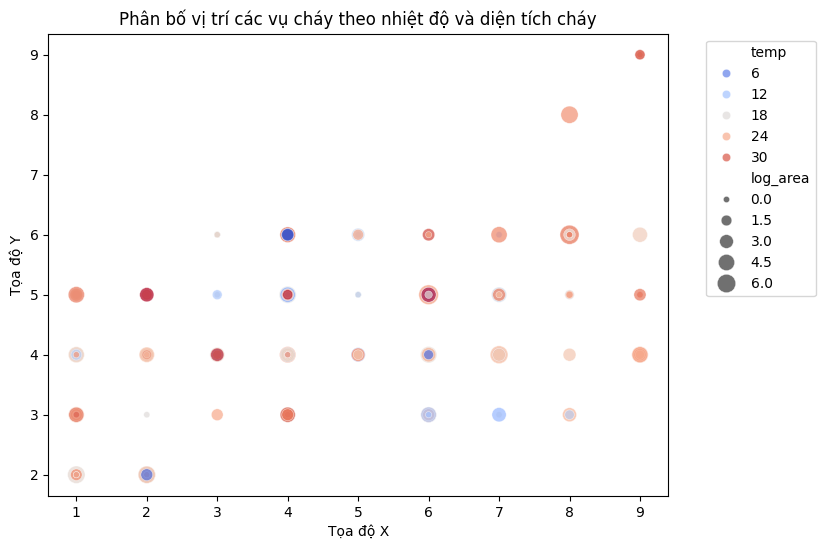

In [85]:
# --- 3.6 Phân bố vị trí các vụ cháy trên bản đồ tọa độ (X, Y) ---

plt.figure(figsize=(8,6))
sns.scatterplot(x='X', y='Y', size='log_area', hue='temp',
                data=df, sizes=(20, 200), alpha=0.7, palette='coolwarm')
plt.title("Phân bố vị trí các vụ cháy theo nhiệt độ và diện tích cháy")
plt.xlabel("Tọa độ X")
plt.ylabel("Tọa độ Y")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# 2. Tiền xử lý

In [86]:
# Xóa cột không cần
df.drop(['month', 'day', 'area'], axis=1, inplace=True)

In [87]:
X = df.drop(columns=['log_area'])
y = df['log_area']

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Chuẩn hóa:

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler trên tập huấn luyện
X_train_scaled = scaler.fit_transform(X_train)

# Áp dụng transform cho tập kiểm tra
X_test_scaled = scaler.transform(X_test)


In [90]:
val_train_df = pd.DataFrame(X_train_scaled, columns=scaler.get_feature_names_out(),index= X_train.index)
val_train_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos
329,-0.288472,-1.094859,0.280286,-0.150282,0.810272,-0.095838,0.797602,-1.059419,0.001631,-0.067817,-0.649665,0.531731,-1.043826,0.713422
173,-0.288472,-0.266696,0.061652,0.217866,0.549136,-0.455434,-0.205272,-0.335215,-1.008923,-0.067817,-0.649665,0.531731,1.164342,0.713422
272,-1.161285,0.561466,0.263468,0.614919,0.435442,1.419602,0.227001,0.147588,0.001631,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
497,-0.724878,-0.266696,0.936186,1.048482,0.487669,1.419602,2.319206,-1.059419,-1.008923,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
182,0.147934,-0.266696,-0.627884,-1.469227,-2.014816,-1.251682,-1.121692,0.509690,-1.008923,-0.067817,2.011400,1.762028,0.060258,1.256843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-0.288472,0.561466,0.633463,-0.411941,0.572437,1.830569,-0.205272,-0.455916,-0.222936,-0.067817,-0.649665,0.531731,-1.316512,-0.507633
106,-0.288472,0.561466,0.145742,-1.239514,-1.910361,-0.327007,-0.118818,-0.938719,-0.503646,-0.067817,2.202456,0.531731,-0.552462,-1.486843
270,-1.161285,-1.923022,0.263468,0.614919,0.435442,1.419602,0.503656,0.690741,-0.503646,-0.067817,-0.458609,-0.698566,1.437028,-0.507633
435,-1.161285,0.561466,0.044834,-0.418026,-0.695879,-0.815030,0.849475,0.388990,-1.233490,-0.067817,0.063366,-1.599206,-1.043826,0.713422


In [91]:
val_test_df = pd.DataFrame(X_test_scaled, columns=scaler.get_feature_names_out(),index= X_test.index)
val_test_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,month_sin,month_cos,day_sin,day_cos
304,0.584341,0.561466,-0.913789,-1.280589,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817,1.489426,-1.599206,-1.043826,0.713422
501,1.020747,0.561466,0.936186,1.048482,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824,-0.458609,-0.698566,1.437028,-0.507633
441,1.457153,1.389629,0.263468,1.442492,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817,-0.458609,-0.698566,1.164342,0.713422
153,0.147934,-0.266696,0.633463,-0.411941,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817,-0.649665,0.531731,-1.316512,-0.507633
503,-1.161285,-0.266696,0.667098,0.414111,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817,-0.458609,-0.698566,0.672978,-1.486843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0.584341,0.561466,0.919368,0.226994,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817,-0.458609,-0.698566,0.672978,-1.486843
275,-0.288472,1.389629,-0.997879,-1.304929,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817,0.776396,2.992325,-0.552462,-1.486843
509,0.147934,-0.266696,0.078470,0.832461,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054,-0.458609,-0.698566,-1.316512,-0.507633
513,-1.161285,-0.266696,-1.502417,-0.843983,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817,-0.458609,-0.698566,0.060258,1.256843


# 3 Huấn luyện mô hình

## 3.1 Mô hình LinearRegression

In [92]:
from sklearn.linear_model import LinearRegression

# Khởi tạo mô hình hồi quy tuyến tính
lin_reg = LinearRegression()


In [93]:
# Huấn luyện trên dữ liệu train đã chuẩn hóa
lin_reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
k=lin_reg.predict(X_test_scaled)

In [95]:
from sklearn.metrics import r2_score 
r2_score(y_test, k )

0.02312352631115966

In [96]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y_test, k)

2.1470392625154

## 3.2 Mô hình SVR

In [97]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


In [98]:
# Chuẩn hóa dữ liệu huấn luyện và kiểm tra
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [99]:
# Lưới tham số để tìm kiếm
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Dò tham số bằng 5-fold cross validation
grid = GridSearchCV(SVR(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("🔹 Best parameters:", grid.best_params_)


🔹 Best parameters: {'C': 0.1, 'epsilon': 1, 'kernel': 'rbf'}


In [100]:
best_params = grid.best_params_

svr_best = SVR(
    kernel=best_params['kernel'],
    C=best_params['C'],
    epsilon=best_params['epsilon']
)

svr_best.fit(X_train_scaled, y_train)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,0.1
,epsilon,1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [101]:
# Dự đoán trên tập kiểm tra
y_pred = svr_best.predict(X_test_scaled)

# Đánh giá độ chính xác
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n🔹 SVR Model Evaluation 🔹")
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))



🔹 SVR Model Evaluation 🔹
RMSE: 1.4833
R²: -0.001


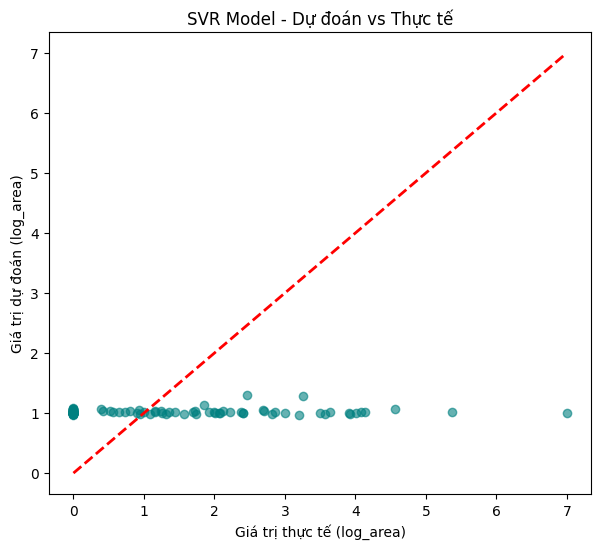

In [102]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Giá trị thực tế (log_area)")
plt.ylabel("Giá trị dự đoán (log_area)")
plt.title("SVR Model - Dự đoán vs Thực tế")
plt.show()


In [103]:
y_pred_area = np.exp(y_pred) - 1
y_test_area = np.exp(y_test) - 1


In [104]:
y_pred_area
y_test_area

304     0.00
501     0.00
441     1.23
153     1.46
503     1.95
       ...  
167     2.51
275     5.38
509     2.17
513    54.29
320    34.36
Name: log_area, Length: 104, dtype: float64

## 3.3 Mô hình RandomForestRegressor

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [106]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [107]:
# Khởi tạo mô hình RandomForestRegressor
oneclass_svm = RandomForestRegressor(
    n_estimators= 400,
    random_state=42
)

# Huấn luyện mô hình (fit unsupervised)
oneclass_svm.fit(val_train_df, y_train)


,n_estimators,400
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [108]:
# Dự đoán: +1 là bình thường, -1 là bất thường
y_pred = oneclass_svm.predict(val_test_df)

y

0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
512    2.006871
513    4.012592
514    2.498152
515    0.000000
516    0.000000
Name: log_area, Length: 517, dtype: float64

In [109]:
r2_score(y_test,y_pred)


-0.03775468327108644

In [110]:
mean_squared_error(y_test,y_pred)

2.280841139953547

# phần 2 (khi dữ liệu được chia theo mùa để train)

In [111]:
import numpy as np

# Log-transform biến mục tiêu
df1['log_area'] = np.log(df1['area'] + 1)


In [112]:
df1_1=df1.drop('area',axis=1)
df1_1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,log_area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.000000
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.000000
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.000000
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.000000
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,2.006871
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,4.012592
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,2.498152
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.000000


In [113]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df1_1['season'] = df1_1['month'].map(month_to_season)


In [114]:
# Xóa cột không cần
X1 =df1_1.drop(['log_area'], axis=1)

In [115]:
y1 = df1_1['log_area']

In [116]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [117]:
from sklearn.preprocessing import OneHotEncoder
encode_data_train=X1_train[['month', 'day', 'season']]
encoder = OneHotEncoder()
encoded = encoder.fit_transform(encode_data_train)

encoded


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1239 stored elements and shape (413, 20)>

In [118]:
train1_df = pd.DataFrame.sparse.from_spmatrix(encoded, columns=encoder.get_feature_names_out(),index= X_train.index)
train1_df

,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed,season_Autumn
329,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,1.0
173,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,0,0,0,0,1.0
272,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0
497,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0
182,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,0,0,0,1.0,1.0,0,0,0,0,0,0,1.0
106,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,1.0
270,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0
435,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0


In [119]:
encode_test=encoder.transform(X1_test[['month', 'day', 'season']])
encode_test_df=pd.DataFrame.sparse.from_spmatrix(encode_test, columns=encoder.get_feature_names_out(['month', 'day', 'season']),index=X1_test.index)

In [120]:
from sklearn.preprocessing import StandardScaler
scale_train_data=X1_train.drop(['month', 'day', 'season'],axis=1)
scaler1 = StandardScaler()

# Fit scaler trên tập huấn luyện
X1_train_scaled = scaler1.fit_transform(scale_train_data)

# Áp dụng transform cho tập kiểm tra
scale_test_data=X1_test.drop(['month', 'day', 'season'],axis=1)
X1_test_scaled = scaler1.transform(scale_test_data)


In [121]:
train2_df = pd.DataFrame(X1_train_scaled, columns=scaler1.get_feature_names_out(),index= X_train.index)
train2_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
329,-0.288472,-1.094859,0.280286,-0.150282,0.810272,-0.095838,0.797602,-1.059419,0.001631,-0.067817
173,-0.288472,-0.266696,0.061652,0.217866,0.549136,-0.455434,-0.205272,-0.335215,-1.008923,-0.067817
272,-1.161285,0.561466,0.263468,0.614919,0.435442,1.419602,0.227001,0.147588,0.001631,-0.067817
497,-0.724878,-0.266696,0.936186,1.048482,0.487669,1.419602,2.319206,-1.059419,-1.008923,-0.067817
182,0.147934,-0.266696,-0.627884,-1.469227,-2.014816,-1.251682,-1.121692,0.509690,-1.008923,-0.067817
...,...,...,...,...,...,...,...,...,...,...
71,-0.288472,0.561466,0.633463,-0.411941,0.572437,1.830569,-0.205272,-0.455916,-0.222936,-0.067817
106,-0.288472,0.561466,0.145742,-1.239514,-1.910361,-0.327007,-0.118818,-0.938719,-0.503646,-0.067817
270,-1.161285,-1.923022,0.263468,0.614919,0.435442,1.419602,0.503656,0.690741,-0.503646,-0.067817
435,-1.161285,0.561466,0.044834,-0.418026,-0.695879,-0.815030,0.849475,0.388990,-1.233490,-0.067817


In [122]:
test2_df = pd.DataFrame(X1_test_scaled, columns=scaler1.get_feature_names_out(),index= X_test.index)
test2_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
304,0.584341,0.561466,-0.913789,-1.280589,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817
501,1.020747,0.561466,0.936186,1.048482,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824
441,1.457153,1.389629,0.263468,1.442492,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817
153,0.147934,-0.266696,0.633463,-0.411941,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817
503,-1.161285,-0.266696,0.667098,0.414111,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817
...,...,...,...,...,...,...,...,...,...,...
167,0.584341,0.561466,0.919368,0.226994,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817
275,-0.288472,1.389629,-0.997879,-1.304929,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817
509,0.147934,-0.266696,0.078470,0.832461,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054
513,-1.161285,-0.266696,-1.502417,-0.843983,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817


In [123]:
test1_df = pd.DataFrame(X1_test_scaled, columns=scaler1.get_feature_names_out(),index= X_test.index)
test1_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
304,0.584341,0.561466,-0.913789,-1.280589,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817
501,1.020747,0.561466,0.936186,1.048482,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824
441,1.457153,1.389629,0.263468,1.442492,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817
153,0.147934,-0.266696,0.633463,-0.411941,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817
503,-1.161285,-0.266696,0.667098,0.414111,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817
...,...,...,...,...,...,...,...,...,...,...
167,0.584341,0.561466,0.919368,0.226994,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817
275,-0.288472,1.389629,-0.997879,-1.304929,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817
509,0.147934,-0.266696,0.078470,0.832461,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054
513,-1.161285,-0.266696,-1.502417,-0.843983,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817


In [124]:
finish_df=pd.concat([train1_df,train2_df],axis=1,join='inner')
finish_df

,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,...,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
329,0,0,0,0,0,0,0,0,0,0,...,-0.288472,-1.094859,0.280286,-0.150282,0.810272,-0.095838,0.797602,-1.059419,0.001631,-0.067817
173,0,0,0,0,0,0,0,0,0,0,...,-0.288472,-0.266696,0.061652,0.217866,0.549136,-0.455434,-0.205272,-0.335215,-1.008923,-0.067817
272,0,1.0,0,0,0,0,0,0,0,0,...,-1.161285,0.561466,0.263468,0.614919,0.435442,1.419602,0.227001,0.147588,0.001631,-0.067817
497,0,1.0,0,0,0,0,0,0,0,0,...,-0.724878,-0.266696,0.936186,1.048482,0.487669,1.419602,2.319206,-1.059419,-1.008923,-0.067817
182,0,0,0,1.0,0,0,0,0,0,0,...,0.147934,-0.266696,-0.627884,-1.469227,-2.014816,-1.251682,-1.121692,0.509690,-1.008923,-0.067817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,0,0,...,-0.288472,0.561466,0.633463,-0.411941,0.572437,1.830569,-0.205272,-0.455916,-0.222936,-0.067817
106,0,0,0,0,0,0,0,1.0,0,0,...,-0.288472,0.561466,0.145742,-1.239514,-1.910361,-0.327007,-0.118818,-0.938719,-0.503646,-0.067817
270,0,1.0,0,0,0,0,0,0,0,0,...,-1.161285,-1.923022,0.263468,0.614919,0.435442,1.419602,0.503656,0.690741,-0.503646,-0.067817
435,0,0,0,0,0,1.0,0,0,0,0,...,-1.161285,0.561466,0.044834,-0.418026,-0.695879,-0.815030,0.849475,0.388990,-1.233490,-0.067817


In [125]:
final_df=pd.concat([encode_test_df,test1_df],axis=1,join='inner')
final_df

,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,...,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
304,0,0,0,0,0,0,0,0,1.0,0,...,0.584341,0.561466,-0.913789,-1.280589,-1.751671,-1.354424,-1.311893,2.984055,0.506908,-0.067817
501,0,1.0,0,0,0,0,0,0,0,0,...,1.020747,0.561466,0.936186,1.048482,0.487669,1.419602,0.469074,1.233895,0.506908,2.421824
441,0,1.0,0,0,0,0,0,0,0,0,...,1.457153,1.389629,0.263468,1.442492,0.493293,-0.147209,1.143421,-0.938719,-1.233490,-0.067817
153,0,0,0,0,0,0,0,0,0,0,...,0.147934,-0.266696,0.633463,-0.411941,0.572437,1.830569,0.209710,0.147588,0.506908,-0.067817
503,0,1.0,0,0,0,0,0,0,0,0,...,-1.161285,-0.266696,0.667098,0.414111,0.559582,2.883671,1.783186,-0.878368,0.506908,-0.067817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0,1.0,0,0,0,0,0,0,0,0,...,0.584341,0.561466,0.919368,0.226994,0.083109,1.984681,0.780311,-0.697317,0.282341,-0.067817
275,0,0,1.0,0,0,0,0,0,0,0,...,-0.288472,1.389629,-0.997879,-1.304929,-0.794709,-1.739706,-2.383931,0.992493,0.506908,-0.067817
509,0,1.0,0,0,0,0,0,0,0,0,...,0.147934,-0.266696,0.078470,0.832461,0.814691,-0.429749,0.382620,1.595997,2.022739,4.289054
513,0,1.0,0,0,0,0,0,0,0,0,...,-1.161285,-0.266696,-1.502417,-0.843983,0.465171,-1.765391,0.520947,1.595997,1.012185,-0.067817


In [126]:
from sklearn.linear_model import LinearRegression

# Khởi tạo mô hình hồi quy tuyến tính
lin_reg1 = LinearRegression()


In [127]:
# Huấn luyện trên dữ liệu train đã chuẩn hóa
lin_reg1.fit(finish_df, y1_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
k1=lin_reg1.predict(final_df)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [129]:
from sklearn.metrics import r2_score 
r2_score(y1_test, k1 )

-0.04715997147346074

In [130]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y1_test, k)

2.1470392625154

In [131]:
from sklearn.svm import SVR

svr1 = SVR(kernel='rbf',C=0.1,epsilon=1)  # hoặc thử 'linear', 'poly'
svr1.fit(finish_df, y1_train)


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,0.1
,epsilon,1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [132]:
from sklearn.model_selection import GridSearchCV

param_grid1 = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid1 = GridSearchCV(SVR(), param_grid, cv=5)
grid1.fit(finish_df, y1_train)

print("Best params:", grid.best_params_)


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919

Best params: {'C': 0.1, 'epsilon': 1, 'kernel': 'rbf'}


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [133]:
val_pre=svr1.predict(final_df)
val_pre

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([1.04066713, 0.99362416, 1.01829021, 1.00510789, 1.0052321 ,
       0.98859893, 1.00182934, 0.99424181, 1.03048062, 1.00213034,
       1.03258953, 1.01512854, 1.03960621, 0.98311855, 1.03498556,
       1.0033358 , 1.01530948, 0.98571413, 0.99986772, 1.01584702,
       1.02891317, 0.99632131, 1.25336675, 0.99765653, 1.00794585,
       0.99359203, 1.01097604, 1.00330463, 0.99968398, 1.03747962,
       1.01385621, 0.99420686, 1.05687679, 1.01569269, 1.00431821,
       1.00046134, 0.99953852, 1.00317757, 1.01014051, 1.00366424,
       1.04393151, 1.00268556, 1.00162195, 1.01226636, 1.03336592,
       1.0118445 , 0.99133534, 1.05880127, 0.99320693, 1.0185773 ,
       1.0278854 , 1.00830133, 1.02116451, 0.98395131, 0.99688976,
       0.99652741, 1.00283596, 1.0474179 , 1.0139542 , 0.99947097,
       1.0120537 , 1.01044365, 0.99558852, 1.00990599, 0.99288098,
       1.04194619, 0.98881027, 1.0355687 , 1.02623817, 1.11708928,
       1.00439353, 1.01717764, 1.03980041, 1.02183739, 1.01763

In [134]:
r2_score(y1_test,val_pre)

0.0022156982650822776

In [135]:
mean_squared_error(y1_test,val_pre)

2.1929917743405003

In [136]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=100,random_state=0)


In [137]:
rfr.fit(finish_df,y1_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
val_pre1=rfr.predict(final_df)
val_pre1

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([1.2471448 , 0.46773594, 1.26869319, 1.6278124 , 0.8807368 ,
       0.34933809, 1.25586239, 0.82677552, 1.08243673, 0.99326513,
       1.30002817, 1.51019631, 0.69884699, 0.52053456, 1.07811408,
       1.12107224, 0.96288958, 0.58093651, 0.71482248, 0.81054818,
       0.89067287, 0.80550821, 2.31507244, 0.52404071, 1.13224082,
       1.13240957, 1.08244423, 1.71918296, 1.93325537, 1.16162246,
       1.17503766, 1.7810076 , 1.6552277 , 1.03558945, 0.43542317,
       0.65611729, 1.30575621, 0.71162714, 1.38802122, 0.39740185,
       2.08765509, 0.34517534, 1.33431264, 1.30874044, 1.83742399,
       1.71624315, 1.10034612, 0.89669645, 0.55727596, 1.0280988 ,
       1.10516335, 1.28836502, 1.29713295, 0.32554902, 0.90743209,
       0.80025042, 1.05979994, 1.25338724, 1.61181179, 1.31411256,
       0.56792952, 1.44925146, 1.05108823, 0.64548106, 0.49786834,
       1.28260092, 0.63622747, 1.87698993, 1.37884611, 1.31589072,
       0.93110119, 1.75576226, 1.37275185, 0.74894244, 0.57172

In [139]:
r2_score(y1_test,val_pre1)

-0.03228650431341107

In [140]:
mean_squared_error(y1_test,val_pre1)

2.268822839551393

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [78]:
pip install ucimlrepo

In [79]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
forest_fires = fetch_ucirepo(id=162)

# data (as pandas dataframes)
X = forest_fires.data.features
y = forest_fires.data.targets

# metadata
print(forest_fires.metadata)

# variable information
print(forest_fires.variables)


{'uci_id': 162, 'name': 'Forest Fires', 'repository_url': 'https://archive.ics.uci.edu/dataset/162/forest+fires', 'data_url': 'https://archive.ics.uci.edu/static/public/162/data.csv', 'abstract': 'This is a difficult regression task, where the aim is to predict the burned area of forest fires, in the northeast region of Portugal, by using meteorological and other data (see details at: http://www.dsi.uminho.pt/~pcortez/forestfires).', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 517, 'num_features': 12, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['area'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2007, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5D88D', 'creators': ['Paulo Cortez', 'Anbal Morais'], 'intro_paper': {'ID': 368, 'type': 'NATIVE', 'title': 'A data mining approach to predict forest fires using meteorological da

In [80]:
data=pd.DataFrame(X)
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [81]:
data.shape

(517, 12)

In [82]:
data.dtypes

,0
X,int64
Y,int64
month,object
day,object
FFMC,float64
DMC,float64
DC,float64
ISI,float64
temp,float64
RH,int64


In [83]:
data.isnull().values.any()

np.False_

In [84]:
import seaborn as sns

<Axes: >

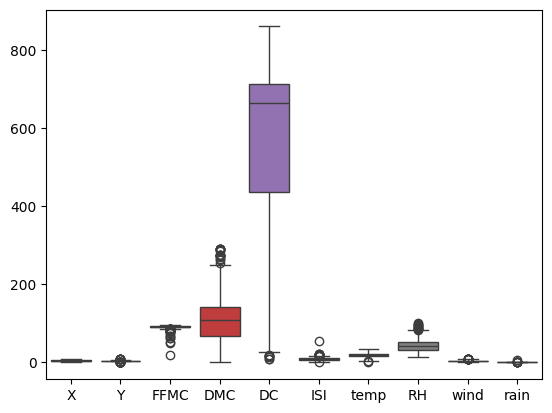

In [85]:
sns.boxplot(data)

In [164]:
Q1_FFMC1=data ['FFMC'].quantile(0.25)
Q3_FFMC1=data ['FFMC'].quantile(0.75)
IQR_FFMC1=Q3_FFMC1-Q1_FFMC1
lower_FFMC1=Q1_FFMC1-1.5*IQR_FFMC1
upper_FFMC1=Q3_FFMC1+1.5*IQR_FFMC1
outlier1=data[(data['FFMC']<lower_FFMC1)|(data['FFMC']>upper_FFMC)]


In [165]:
Q1_DMC1=data ['DMC'].quantile(0.25)
Q3_DMC1=data ['DMC'].quantile(0.75)
IQR_DMC1=Q3_DMC1-Q1_DMC1
lower_DMC1=Q1_DMC1-1.5*IQR_DMC1
upper_DMC1=Q3_DMC1+1.5*IQR_DMC1
outlier2=data[(data['DMC']<lower_DMC1)|(data['DMC']>upper_DMC)]

In [166]:
Q1_ISI1=data ['ISI'].quantile(0.25)
Q3_ISI1=data ['ISI'].quantile(0.75)
IQR_ISI1=Q3_ISI1-Q1_ISI1
lower_ISI1=Q1_ISI1-1.5*IQR_ISI1
upper_ISI1=Q3_ISI1+1.5*IQR_ISI1
outlier3=data[(data['ISI']<lower_ISI1)|(data['ISI']>upper_ISI)]

In [168]:
Q1_RH1=data ['RH'].quantile(0.25)
Q3_RH1=data ['RH'].quantile(0.75)
IQR_RH1=Q3_RH1-Q1_RH1
lower_RH1=Q1_RH1-1.5*IQR_RH1
upper_RH=Q3_RH1+1.5*IQR_RH1
outlier4=data[(data['RH']<lower_RH1)|(data['RH']>upper_RH)]

In [169]:
outlier1.index

Index([  0,  19,  39,  48,  49,  59,  76,  77, 114, 115, 126, 131, 134, 182,
       213, 222, 240, 255, 283, 324, 404, 406, 442, 466],
      dtype='int64')

In [170]:
outlier2.index

Index([], dtype='int64')

In [171]:
outlier3.index

Index([12, 97, 130, 199, 299, 312, 516], dtype='int64')

In [172]:
outlier4.index

Index([463, 478], dtype='int64')

In [173]:
data.loc[outlier1.index,'FFMC']=np.nan

In [174]:
data.loc[outlier1.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,NaN,26.2000,94.3,5.1,8.2,51.0,6.7,0.0
19,6,4,apr,sat,NaN,27.4000,97.1,5.1,9.3,44.0,4.5,0.0
39,4,4,mar,tue,NaN,25.7000,67.6,3.8,14.1,43.0,2.7,0.0
48,4,4,mar,mon,NaN,23.9000,64.7,4.1,11.8,35.0,1.8,0.0
49,4,4,mar,mon,NaN,52.2000,103.8,5.0,11.0,46.0,5.8,0.0
59,2,2,feb,fri,NaN,13.2000,43.0,5.3,12.3,51.0,0.9,0.0
76,9,9,feb,fri,NaN,13.2000,43.0,5.3,15.7,43.0,3.1,0.0
77,1,3,mar,mon,NaN,52.2000,103.8,5.0,8.3,72.0,3.1,0.0
114,3,4,mar,tue,NaN,25.7000,67.6,3.8,15.8,27.0,7.6,0.0
115,3,5,mar,tue,NaN,25.7000,67.6,3.8,15.5,27.0,6.3,0.0


In [97]:
from sklearn.impute import SimpleImputer

In [98]:
imputer = SimpleImputer(strategy= 'mean', fill_value=np.nan)
data['FFMC']= imputer.fit_transform(data[['FFMC']])
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42,4.0,0.0


In [99]:
data.loc[outlier2.index,'DMC']=np.nan

In [100]:
data.loc[outlier2.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
369,4,5,sep,sun,91.0,NaN,825.1,7.1,13.8,77,7.6,0.0
370,7,4,sep,sun,91.0,NaN,825.1,7.1,13.8,77,7.6,0.0
374,6,5,sep,fri,90.3,NaN,855.3,7.4,10.3,78,4.0,0.0
384,8,4,aug,sat,91.6,NaN,819.1,7.7,21.3,44,4.5,0.0
392,1,3,sep,sun,91.0,NaN,825.1,7.1,21.9,43,4.0,0.0
406,6,5,sep,sat,87.1,NaN,860.6,4.0,17.0,67,4.9,0.0
408,4,3,sep,fri,90.3,NaN,855.3,7.4,19.9,44,3.1,0.0
422,8,6,jul,sun,88.9,NaN,795.9,5.2,29.3,27,3.6,0.0
430,7,4,sep,thu,89.7,NaN,849.3,6.8,19.4,45,3.6,0.0
434,1,4,aug,fri,90.6,NaN,811.2,5.5,22.2,45,3.6,0.0


In [101]:
imputer = SimpleImputer(strategy= 'mean', fill_value=np.nan)
data['DMC']= imputer.fit_transform(data[['DMC']])
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42,4.0,0.0


In [102]:
data.loc[outlier3.index,'ISI']=np.nan

In [103]:
data.loc[outlier3.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
11,7,5,sep,sat,92.800000,73.2,713.0,NaN,19.3,38,4.0,0.0
22,7,4,jun,sun,94.300000,96.3,200.0,NaN,21.0,44,4.5,0.0
24,7,4,aug,sat,93.500000,139.4,594.2,NaN,23.7,32,5.8,0.0
133,4,6,sep,thu,93.700000,80.9,685.2,NaN,17.6,42,3.1,0.0
135,3,5,aug,sat,93.500000,139.4,594.2,NaN,17.6,52,5.8,0.0
149,8,6,sep,thu,93.700000,80.9,685.2,NaN,23.7,25,4.5,0.0
206,2,2,aug,sat,93.500000,139.4,594.2,NaN,22.9,31,7.2,0.0
209,8,3,sep,thu,93.700000,80.9,685.2,NaN,23.2,26,4.9,0.0
211,7,4,aug,sat,93.500000,139.4,594.2,NaN,5.1,96,5.8,0.0
266,6,5,aug,tue,94.300000,131.7,607.1,NaN,19.4,55,4.0,0.0


In [104]:
imputer = SimpleImputer(strategy= 'mean', fill_value=np.nan)
data['ISI']= imputer.fit_transform(data[['ISI']])
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42,4.0,0.0


In [105]:
data.loc[outlier4.index,'RH']=np.nan

In [106]:
data.loc[outlier4.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
3,8,6,mar,fri,91.700000,33.3,77.5,9.000000,8.3,NaN,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.600000,11.4,NaN,1.8,0.0
7,8,6,aug,mon,91.500000,145.4,608.2,10.700000,8.0,NaN,2.2,0.0
98,3,4,aug,sun,91.400000,142.4,601.4,10.600000,11.6,NaN,4.5,0.0
211,7,4,aug,sat,93.500000,139.4,594.2,8.514372,5.1,NaN,5.8,0.0
261,3,4,aug,fri,91.600000,112.4,573.0,8.900000,11.2,NaN,7.6,0.0
286,7,6,jul,wed,91.200000,183.1,437.7,12.500000,12.6,NaN,7.6,0.2
299,6,5,jun,sat,91.890733,71.0,233.8,0.400000,10.6,NaN,2.7,0.0
304,6,5,may,sat,91.890733,28.0,113.8,3.500000,11.3,NaN,4.9,0.0
335,4,3,sep,mon,91.600000,108.4,764.0,6.200000,9.8,NaN,1.8,0.0


In [107]:
imputer = SimpleImputer(strategy= 'mean', fill_value=np.nan)
data['RH']= imputer.fit_transform(data[['RH']])
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.200000,26.2,94.3,5.1,8.2,51.000000,6.7,0.0
1,7,4,oct,tue,90.600000,35.4,669.1,6.7,18.0,33.000000,0.9,0.0
2,7,4,oct,sat,90.600000,43.7,686.9,6.7,14.6,33.000000,1.3,0.0
3,8,6,mar,fri,91.700000,33.3,77.5,9.0,8.3,43.168317,4.0,0.2
4,8,6,mar,sun,89.300000,51.3,102.2,9.6,11.4,43.168317,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.890733,56.7,665.6,1.9,27.8,32.000000,2.7,0.0
513,2,4,aug,sun,91.890733,56.7,665.6,1.9,21.9,71.000000,5.8,0.0
514,7,4,aug,sun,91.890733,56.7,665.6,1.9,21.2,70.000000,6.7,0.0
515,1,4,aug,sat,94.400000,146.0,614.7,11.3,25.6,42.000000,4.0,0.0


In [108]:
df= pd.DataFrame(y)
df

,area
0,0.00
1,0.00
2,0.00
3,0.00
4,0.00
...,...
512,6.44
513,54.29
514,11.16
515,0.00


In [109]:
target=np.log(y+1)
target

,area
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
512,2.006871
513,4.012592
514,2.498152
515,0.000000


In [110]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data,target,test_size=0.2,random_state=0)

In [137]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [138]:
train_data=x_train.drop(['month','day'],axis=1)
train_data

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,3,4,90.500000,96.7,750.5,11.4,20.6,55.0,5.4,0.0
56,4,3,90.300000,80.7,730.2,6.3,17.8,63.0,4.9,0.0
457,1,4,91.700000,191.4,635.9,7.8,19.9,50.0,4.0,0.0
60,2,2,89.300000,51.3,102.2,9.6,11.5,39.0,5.8,0.0
229,8,6,92.200000,81.8,480.8,11.9,16.4,43.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
70,4,5,91.200000,48.3,97.8,12.5,15.8,27.0,7.6,0.0
277,3,4,91.890733,25.4,349.7,2.6,4.6,21.0,8.5,0.0
9,7,5,92.500000,88.0,698.6,7.1,22.8,40.0,4.0,0.0
359,1,4,92.500000,122.0,789.7,10.2,21.1,39.0,2.2,0.0


In [139]:
scaler.fit(train_data)
val_scale=scaler.transform(train_data)
val_scale

array([[-0.69046229, -0.23274839, -0.77019356, ...,  0.86047994,
         0.77617805, -0.07126589],
       [-0.25905393, -1.0543303 , -0.8820731 , ...,  1.42002271,
         0.49997477, -0.07126589],
       [-1.55327901, -0.23274839, -0.09891629, ...,  0.51076571,
         0.00280885, -0.07126589],
       ...,
       [ 1.03517115,  0.58883352,  0.34860188, ..., -0.18866275,
         0.00280885, -0.07126589],
       [-1.55327901, -0.23274839,  0.34860188, ..., -0.2586056 ,
        -0.99152299, -0.07126589],
       [-1.12187065, -1.87591221,  1.63521664, ..., -1.44763398,
         0.27901213, -0.07126589]])

In [141]:
scale_df = pd.DataFrame(val_scale, columns=scaler.get_feature_names_out(),index=x_train.index)
scale_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,-0.690462,-0.232748,-0.770194,-0.166779,0.833686,0.867353,0.297337,0.860480,0.776178,-0.071266
56,-0.259054,-1.054330,-0.882073,-0.444787,0.752438,-0.655052,-0.185653,1.420023,0.499975,-0.071266
457,-1.553279,-0.232748,-0.098916,1.478678,0.375017,-0.207286,0.176590,0.510766,0.002809,-0.071266
60,-1.121871,-1.875912,-1.441471,-0.955626,-1.761036,0.330033,-1.272382,-0.258606,0.997141,-0.071266
229,1.466580,1.410415,0.180783,-0.425674,-0.245747,1.016608,-0.427148,0.021166,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
70,-0.259054,0.588834,-0.378615,-1.007752,-1.778646,1.195714,-0.530646,-1.097920,1.991473,-0.071266
277,-0.690462,-0.232748,0.007779,-1.405650,-0.770455,-1.759542,-2.462608,-1.517577,2.488638,-0.071266
9,1.035171,0.588834,0.348602,-0.317946,0.625964,-0.416244,0.676830,-0.188663,0.002809,-0.071266
359,-1.553279,-0.232748,0.348602,0.272820,0.990578,0.509140,0.383586,-0.258606,-0.991523,-0.071266


In [142]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [143]:
test_data=x_test.drop(['month','day'],axis=1)
test_data

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,7,3,87.600000,52.2,103.8,5.0,11.0,46.0,5.8,0.0
435,2,5,90.800000,84.7,376.6,5.6,23.8,51.0,1.8,0.0
343,8,6,91.500000,130.1,807.1,7.5,15.9,51.0,4.5,0.0
230,4,4,92.900000,133.3,699.6,9.2,26.4,21.0,4.5,0.0
171,8,6,91.890733,90.4,609.6,6.6,17.4,50.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
154,1,5,93.400000,145.4,721.4,8.1,29.6,27.0,2.7,0.0
49,4,4,87.600000,52.2,103.8,5.0,11.0,46.0,5.8,0.0
100,3,4,91.400000,142.4,601.4,10.6,19.8,39.0,5.4,0.0
153,5,4,94.300000,85.1,692.3,15.9,20.1,47.0,4.9,0.0


In [144]:
test_scale=scaler.transform(test_data)
test_scale

array([[ 1.03517115, -1.0543303 , -2.39244695, ...,  0.23099433,
         0.99714068, -0.07126589],
       [-1.12187065,  0.58883352, -0.60237424, ...,  0.58070856,
        -1.21248562, -0.07126589],
       [ 1.46657951,  1.41041543, -0.21079584, ...,  0.58070856,
         0.27901213, -0.07126589],
       ...,
       [-0.69046229, -0.23274839, -0.26673561, ..., -0.2586056 ,
         0.77617805, -0.07126589],
       [ 0.17235443, -0.23274839,  1.35551778, ...,  0.30093717,
         0.49997477, -0.07126589],
       [ 1.46657951,  0.58883352,  0.68424051, ..., -1.23780544,
        -0.49435707, -0.07126589]])

In [145]:
scale_test_df = pd.DataFrame(test_scale, columns=scaler.get_feature_names_out(),index=x_test.index)
scale_test_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,1.035171,-1.054330,-2.392447,-0.939988,-1.754632,-1.043116,-1.358630,0.230994,0.997141,-0.071266
435,-1.121871,0.588834,-0.602374,-0.375285,-0.662792,-0.864010,0.849326,0.580709,-1.212486,-0.071266
343,1.466580,1.410415,-0.210796,0.413562,1.060219,-0.296839,-0.513397,0.580709,0.279012,-0.071266
230,-0.259054,-0.232748,0.572361,0.469163,0.629967,0.210629,1.297817,-1.517577,0.279012,-0.071266
171,1.466580,1.410415,0.007779,-0.276245,0.269755,-0.565499,-0.254652,0.510766,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
154,-1.553279,0.588834,0.852060,0.679406,0.717218,-0.117733,1.849807,-1.097920,-0.715320,-0.071266
49,-0.259054,-0.232748,-2.392447,-0.939988,-1.754632,-1.043116,-1.358630,0.230994,0.997141,-0.071266
100,-0.690462,-0.232748,-0.266736,0.627280,0.236936,0.628544,0.159340,-0.258606,0.776178,-0.071266
153,0.172354,-0.232748,1.355518,-0.368335,0.600749,2.210651,0.211089,0.300937,0.499975,-0.071266


In [146]:
model.fit(scale_df,y_train)

LinearRegression()

In [147]:
pre_val=model.predict(scale_test_df)
pre_val

array([[0.89628563],
       [0.90535873],
       [1.35840394],
       [1.12141587],
       [1.28639825],
       [1.14961828],
       [1.06314672],
       [0.98189511],
       [1.21874919],
       [0.90527904],
       [0.81573485],
       [1.47784417],
       [0.75464497],
       [0.97184201],
       [1.15257183],
       [0.56534636],
       [0.98291124],
       [1.02470854],
       [0.85195226],
       [0.74891535],
       [1.05924087],
       [1.00058067],
       [1.3110946 ],
       [0.88699532],
       [0.95195224],
       [1.03634334],
       [1.15184552],
       [1.299834  ],
       [1.25764495],
       [0.99288237],
       [1.20481751],
       [1.03539572],
       [0.97060634],
       [1.27729085],
       [1.31148986],
       [1.29975051],
       [0.91321846],
       [0.86099052],
       [1.1864829 ],
       [1.25004138],
       [1.13823555],
       [0.94033502],
       [1.11603945],
       [1.13791876],
       [0.9557713 ],
       [1.13123814],
       [1.21239304],
       [0.988

In [148]:
from sklearn.metrics import r2_score
r2_score(y_test,pre_val)

-0.014127162927143111

In [149]:
from sklearn.metrics import mean_absolute_error

In [150]:
mean_absolute_error(y_test,pre_val)

1.2132086776909718

In [151]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [152]:
svr_model = SVR(kernel='rbf')

In [153]:
svr_model.fit(scale_df, y_train.values.ravel())

SVR()

In [154]:
svr_predictions = svr_model.predict(scale_test_df)

In [155]:
mse_svr = mean_squared_error(y_test, svr_predictions)
r2_svr = r2_score(y_test, svr_predictions)

In [156]:
mse_svr

3.045680655966595

In [157]:
r2_svr

-0.26503193511077083

In [158]:
from sklearn.ensemble import RandomForestRegressor

In [159]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(scale_df, y_train.values.ravel())

RandomForestRegressor(random_state=0)

In [160]:
rf_predictions = rf_model.predict(scale_test_df)

In [161]:
mse_rf = mean_squared_error(y_test, rf_predictions)
r2_rf = r2_score(y_test, rf_predictions)

In [162]:
mse_rf

2.5261271127619263

In [163]:
r2_rf

-0.04923392527468362

In [4]:
data1=pd.DataFrame(X)
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [5]:
from sklearn.impute import SimpleImputer


In [62]:
Q1_FFMC2=data1 ['FFMC'].quantile(0.25)
Q3_FFMC2=data1 ['FFMC'].quantile(0.75)
IQR_FFMC2=Q3_FFMC2-Q1_FFMC2
lower_FFMC2=Q1_FFMC2-1.5*IQR_FFMC2
upper_FFMC=Q3_FFMC2+1.5*IQR_FFMC2
outlier1=data1[(data1['FFMC']<lower_FFMC2)|(data1['FFMC']>upper_FFMC)]

In [63]:
Q1_DMC2=data1 ['DMC'].quantile(0.25)
Q3_DMC2=data1 ['DMC'].quantile(0.75)
IQR_DMC2=Q3_DMC2-Q1_DMC2
lower_DMC2=Q1_DMC2-1.5*IQR_DMC2
upper_DMC2=Q3_DMC2+1.5*IQR_DMC2
outlier2=data1[(data1['DMC']<lower_DMC2)|(data1['DMC']>upper_DMC)]

In [64]:

Q1_ISI2=data1 ['ISI'].quantile(0.25)
Q3_ISI2=data1 ['ISI'].quantile(0.75)
IQR_ISI2=Q3_ISI2-Q1_ISI2
lower_ISI2=Q1_ISI2-1.5*IQR_ISI2
upper_ISI=Q3_ISI2+1.5*IQR_ISI2
outlier3=data1[(data1['ISI']<lower_ISI2)|(data1['ISI']>upper_ISI)]

In [65]:
Q1_RH2=data1 ['RH'].quantile(0.25)
Q3_RH2=data1 ['RH'].quantile(0.75)
IQR_RH2=Q3_RH2-Q1_RH2
lower_RH2=Q1_RH2-1.5*IQR_RH2
upper_RH2=Q3_RH2+1.5*IQR_RH2
outlier4=data1[(data1['RH']<lower_RH2)|(data1['RH']>upper_RH)]

In [14]:
data1.loc[outlier1.index,'FFMC']=np.nan

In [70]:
data1.loc[outlier1.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
19,6,4,apr,sat,86.3,27.4,97.1,5.1,9.3,44.0,4.5,0.0
39,4,4,mar,tue,88.1,25.7,67.6,3.8,14.1,43.0,2.7,0.0
48,4,4,mar,mon,87.2,23.9,64.7,4.1,11.8,35.0,1.8,0.0
49,4,4,mar,mon,87.6,52.2,103.8,5.0,11.0,46.0,5.8,0.0
59,2,2,feb,fri,86.6,13.2,43.0,5.3,12.3,51.0,0.9,0.0
76,9,9,feb,fri,86.6,13.2,43.0,5.3,15.7,43.0,3.1,0.0
77,1,3,mar,mon,87.6,52.2,103.8,5.0,8.3,72.0,3.1,0.0
114,3,4,mar,tue,88.1,25.7,67.6,3.8,15.8,27.0,7.6,0.0
115,3,5,mar,tue,88.1,25.7,67.6,3.8,15.5,27.0,6.3,0.0


In [71]:
imputer = SimpleImputer(strategy= 'median', fill_value=np.nan)
data1['FFMC']= imputer.fit_transform(data1[['FFMC']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [72]:
data1.loc[outlier2.index,'DMC']=np.nan

In [73]:
data1.loc[outlier2.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain


In [74]:
imputer = SimpleImputer(strategy= 'median', fill_value=np.nan)
data1['DMC']= imputer.fit_transform(data1[['DMC']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [75]:
data1.loc[outlier3.index,'ISI']=np.nan

In [76]:
data1.loc[outlier3.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
12,6,5,aug,fri,91.8,70.8,665.3,NaN,17.0,72.0,6.7,0.0
30,6,3,sep,fri,94.3,85.1,692.3,NaN,25.4,24.0,3.6,0.0
42,4,4,aug,tue,94.8,108.3,647.1,NaN,16.6,54.0,5.4,0.0
45,5,6,sep,wed,94.3,85.1,692.3,NaN,25.9,24.0,4.0,0.0
71,4,5,sep,fri,94.3,85.1,692.3,NaN,17.7,37.0,3.6,0.0
82,1,2,aug,tue,94.8,108.3,647.1,NaN,18.6,51.0,4.5,0.0
97,3,4,mar,sat,91.8,2.4,15.5,NaN,17.4,24.0,5.4,0.0
102,2,4,aug,tue,94.8,108.3,647.1,NaN,20.1,40.0,4.0,0.0
124,3,4,sep,fri,94.3,85.1,692.3,NaN,19.8,50.0,5.4,0.0
130,4,6,feb,sat,91.8,21.5,87.2,NaN,15.4,40.0,2.7,0.0


In [77]:
imputer = SimpleImputer(strategy= 'median', fill_value=np.nan)
data1['ISI']= imputer.fit_transform(data1[['ISI']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [78]:
data1.loc[outlier4.index,'RH']=np.nan

In [79]:
data1.loc[outlier4.index,:]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain


In [25]:
imputer = SimpleImputer(strategy= 'median', fill_value=np.nan)
data1['RH']= imputer.fit_transform(data1[['RH']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data1,target,test_size=0.2,random_state=0)

In [30]:
def month_to_season(month):
    if month in ['dec', 'jan', 'feb']:
        return 'winter'
    elif month in ['mar', 'apr', 'may']:
        return 'spring'
    elif month in ['jun', 'jul', 'aug']:
        return 'summer'
    else:
        return 'fall'

x_train['season'] = x_train['month'].apply(month_to_season)
x_test['season'] = x_test['month'].apply(month_to_season)

In [31]:
display(x_train.head())

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,season
386,3,4,sep,sun,90.5,96.7,750.5,11.4,20.6,55.0,5.4,0.0,fall
56,4,3,sep,tue,90.3,80.7,730.2,6.3,17.8,63.0,4.9,0.0,fall
457,1,4,aug,wed,91.7,191.4,635.9,7.8,19.9,50.0,4.0,0.0,summer
60,2,2,mar,sun,89.3,51.3,102.2,9.6,11.5,39.0,5.8,0.0,spring
229,8,6,aug,sat,92.2,81.8,480.8,11.9,16.4,43.0,4.0,0.0,summer


In [32]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder()

In [33]:
forest=x_train[['month','day','season']]
forest_1hot=onehot.fit_transform(forest)
forest_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1239 stored elements and shape (413, 23)>

In [34]:
forest_df = pd.DataFrame.sparse.from_spmatrix(forest_1hot,
                                                 columns=onehot.get_feature_names_out(),index=x_train.index)
forest_df

,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,...,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed,season_fall,season_spring,season_summer,season_winter
386,0,0,0,0,0,0,0,0,0,0,...,0,0,1.0,0,0,0,1.0,0,0,0
56,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1.0,0,1.0,0,0,0
457,0,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.0,0,0,1.0,0
60,0,0,0,0,0,0,0,1.0,0,0,...,0,0,1.0,0,0,0,0,1.0,0,0
229,0,1.0,0,0,0,0,0,0,0,0,...,0,1.0,0,0,0,0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0,0,0,0,0,0,0,1.0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
277,0,0,1.0,0,0,0,0,0,0,0,...,1.0,0,0,0,0,0,0,0,0,1.0
9,0,0,0,0,0,0,0,0,0,0,...,0,1.0,0,0,0,0,1.0,0,0,0
359,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,0,0,0


In [35]:
forest_test=x_test[['month','day','season']]
forest_test_1hot=onehot.transform(forest_test)


In [36]:
forest_test_df=pd.DataFrame.sparse.from_spmatrix(forest_test_1hot,
                                                 columns=onehot.get_feature_names_out(),index=x_test.index)
forest_test_df

,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,...,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed,season_fall,season_spring,season_summer,season_winter
213,0,0,0,0,0,0,0,1.0,0,0,...,1.0,0,0,0,0,0,0,1.0,0,0
435,0,0,0,0,0,1.0,0,0,0,0,...,0,1.0,0,0,0,0,0,0,1.0,0
343,0,0,0,0,0,0,0,0,0,0,...,1.0,0,0,0,0,0,1.0,0,0,0
230,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.0,1.0,0,0,0
171,0,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,0,0,0,0,0,0,0,0,0,0,...,0,1.0,0,0,0,0,1.0,0,0,0
49,0,0,0,0,0,0,0,1.0,0,0,...,1.0,0,0,0,0,0,0,1.0,0,0
100,0,1.0,0,0,0,0,0,0,0,0,...,0,0,1.0,0,0,0,0,0,1.0,0
153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,0,0,0


In [38]:
train_scale=x_train.drop(['month','day','season'],axis=1)
train_scale

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,3,4,90.5,96.7,750.5,11.4,20.6,55.0,5.4,0.0
56,4,3,90.3,80.7,730.2,6.3,17.8,63.0,4.9,0.0
457,1,4,91.7,191.4,635.9,7.8,19.9,50.0,4.0,0.0
60,2,2,89.3,51.3,102.2,9.6,11.5,39.0,5.8,0.0
229,8,6,92.2,81.8,480.8,11.9,16.4,43.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
70,4,5,91.2,48.3,97.8,12.5,15.8,27.0,7.6,0.0
277,3,4,91.8,25.4,349.7,2.6,4.6,21.0,8.5,0.0
9,7,5,92.5,88.0,698.6,7.1,22.8,40.0,4.0,0.0
359,1,4,92.5,122.0,789.7,10.2,21.1,39.0,2.2,0.0


In [39]:
scaler.fit(train_scale)
val_train=scaler.transform(train_scale)
val_train

array([[-0.69046229, -0.23274839, -0.7652208 , ...,  0.86473145,
         0.77617805, -0.07126589],
       [-0.25905393, -1.0543303 , -0.87709202, ...,  1.42417393,
         0.49997477, -0.07126589],
       [-1.55327901, -0.23274839, -0.09399349, ...,  0.51507991,
         0.00280885, -0.07126589],
       ...,
       [ 1.03517115,  0.58883352,  0.35349138, ..., -0.18422319,
         0.00280885, -0.07126589],
       [-1.55327901, -0.23274839,  0.35349138, ..., -0.2541535 ,
        -0.99152299, -0.07126589],
       [-1.12187065, -1.87591221,  1.64001039, ..., -1.44296876,
         0.27901213, -0.07126589]])

In [40]:
train_scale_df = pd.DataFrame(val_train, columns=scaler.get_feature_names_out(),index=x_train.index)
train_scale_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,-0.690462,-0.232748,-0.765221,-0.167117,0.833686,0.871744,0.297337,0.864731,0.776178,-0.071266
56,-0.259054,-1.054330,-0.877092,-0.445126,0.752438,-0.650393,-0.185653,1.424174,0.499975,-0.071266
457,-1.553279,-0.232748,-0.093993,1.478349,0.375017,-0.202706,0.176590,0.515080,0.002809,-0.071266
60,-1.121871,-1.875912,-1.436448,-0.955967,-1.761036,0.334519,-1.272382,-0.254153,0.997141,-0.071266
229,1.466580,1.410415,0.185685,-0.426012,-0.245747,1.020973,-0.427148,0.025568,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
70,-0.259054,0.588834,-0.373672,-1.008094,-1.778646,1.200048,-0.530646,-1.093317,1.991473,-0.071266
277,-0.690462,-0.232748,-0.038058,-1.405994,-0.770455,-1.754689,-2.462608,-1.512899,2.488638,-0.071266
9,1.035171,0.588834,0.353491,-0.318284,0.625964,-0.411627,0.676830,-0.184223,0.002809,-0.071266
359,-1.553279,-0.232748,0.353491,0.272485,0.990578,0.513594,0.383586,-0.254153,-0.991523,-0.071266


In [41]:
test_scale=x_test.drop(['month','day','season'],axis=1)
test_scale

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,7,3,87.6,52.2,103.8,5.0,11.0,46.0,5.8,0.0
435,2,5,90.8,84.7,376.6,5.6,23.8,51.0,1.8,0.0
343,8,6,91.5,130.1,807.1,7.5,15.9,51.0,4.5,0.0
230,4,4,92.9,133.3,699.6,9.2,26.4,21.0,4.5,0.0
171,8,6,91.8,90.4,609.6,6.6,17.4,50.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
154,1,5,93.4,145.4,721.4,8.1,29.6,27.0,2.7,0.0
49,4,4,87.6,52.2,103.8,5.0,11.0,46.0,5.8,0.0
100,3,4,91.4,142.4,601.4,10.6,19.8,39.0,5.4,0.0
153,5,4,94.3,85.1,692.3,15.9,20.1,47.0,4.9,0.0


In [42]:
val_test=scaler.transform(test_scale)
val_test

array([[ 1.03517115, -1.0543303 , -2.38735346, ...,  0.23535867,
         0.99714068, -0.07126589],
       [-1.12187065,  0.58883352, -0.59741397, ...,  0.58501021,
        -1.21248562, -0.07126589],
       [ 1.46657951,  1.41041543, -0.20586471, ...,  0.58501021,
         0.27901213, -0.07126589],
       ...,
       [-0.69046229, -0.23274839, -0.26180032, ..., -0.2541535 ,
         0.77617805, -0.07126589],
       [ 0.17235443, -0.23274839,  1.36033234, ...,  0.30528898,
         0.49997477, -0.07126589],
       [ 1.46657951,  0.58883352,  0.68910503, ..., -1.23317783,
        -0.49435707, -0.07126589]])

In [43]:
test_scale_df = pd.DataFrame(val_test, columns=scaler.get_feature_names_out(),index=x_test.index)
test_scale_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,1.035171,-1.054330,-2.387353,-0.940329,-1.754632,-1.038389,-1.358630,0.235359,0.997141,-0.071266
435,-1.121871,0.588834,-0.597414,-0.375623,-0.662792,-0.859314,0.849326,0.585010,-1.212486,-0.071266
343,1.466580,1.410415,-0.205865,0.413227,1.060219,-0.292243,-0.513397,0.585010,0.279012,-0.071266
230,-0.259054,-0.232748,0.577234,0.468829,0.629967,0.215136,1.297817,-1.512899,0.279012,-0.071266
171,1.466580,1.410415,-0.038058,-0.276583,0.269755,-0.560856,-0.254652,0.515080,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
154,-1.553279,0.588834,0.856912,0.679073,0.717218,-0.113168,1.849807,-1.093317,-0.715320,-0.071266
49,-0.259054,-0.232748,-2.387353,-0.940329,-1.754632,-1.038389,-1.358630,0.235359,0.997141,-0.071266
100,-0.690462,-0.232748,-0.261800,0.626946,0.236936,0.632977,0.159340,-0.254153,0.776178,-0.071266
153,0.172354,-0.232748,1.360332,-0.368673,0.600749,2.214806,0.211089,0.305289,0.499975,-0.071266


In [44]:
x_train_processed = pd.concat([forest_df, train_scale_df], axis=1,join='inner')
x_test_processed = pd.concat([forest_test_df, test_scale_df], axis=1,join='inner')

In [45]:
x_train_processed

,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,...,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,0,0,0,0,0,0,0,0,0,0,...,-0.690462,-0.232748,-0.765221,-0.167117,0.833686,0.871744,0.297337,0.864731,0.776178,-0.071266
56,0,0,0,0,0,0,0,0,0,0,...,-0.259054,-1.054330,-0.877092,-0.445126,0.752438,-0.650393,-0.185653,1.424174,0.499975,-0.071266
457,0,1.0,0,0,0,0,0,0,0,0,...,-1.553279,-0.232748,-0.093993,1.478349,0.375017,-0.202706,0.176590,0.515080,0.002809,-0.071266
60,0,0,0,0,0,0,0,1.0,0,0,...,-1.121871,-1.875912,-1.436448,-0.955967,-1.761036,0.334519,-1.272382,-0.254153,0.997141,-0.071266
229,0,1.0,0,0,0,0,0,0,0,0,...,1.466580,1.410415,0.185685,-0.426012,-0.245747,1.020973,-0.427148,0.025568,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0,0,0,0,0,0,0,1.0,0,0,...,-0.259054,0.588834,-0.373672,-1.008094,-1.778646,1.200048,-0.530646,-1.093317,1.991473,-0.071266
277,0,0,1.0,0,0,0,0,0,0,0,...,-0.690462,-0.232748,-0.038058,-1.405994,-0.770455,-1.754689,-2.462608,-1.512899,2.488638,-0.071266
9,0,0,0,0,0,0,0,0,0,0,...,1.035171,0.588834,0.353491,-0.318284,0.625964,-0.411627,0.676830,-0.184223,0.002809,-0.071266
359,0,0,0,0,0,0,0,0,0,0,...,-1.553279,-0.232748,0.353491,0.272485,0.990578,0.513594,0.383586,-0.254153,-0.991523,-0.071266


In [47]:
model.fit(x_train_processed,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


LinearRegression()

In [48]:
pre_val=model.predict(x_test_processed)
pre_val

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([[0.75290646],
       [1.16977821],
       [1.34108941],
       [1.49344937],
       [0.80499356],
       [1.58515477],
       [1.04673989],
       [0.75275955],
       [1.12827965],
       [1.6055867 ],
       [0.77928457],
       [2.37627007],
       [0.57289477],
       [0.6132365 ],
       [0.88558718],
       [0.50131164],
       [0.61511445],
       [0.81651647],
       [1.50470614],
       [0.98932624],
       [0.77828298],
       [1.24893061],
       [1.58166176],
       [0.85241403],
       [0.90475017],
       [0.94557947],
       [1.53789393],
       [1.37362079],
       [1.38791694],
       [1.02407437],
       [1.47138207],
       [1.06223794],
       [0.93340058],
       [1.54454642],
       [1.31473961],
       [1.13247715],
       [0.84829157],
       [0.48931717],
       [1.69389083],
       [1.32579265],
       [0.42491913],
       [0.78662196],
       [1.10506175],
       [1.35805569],
       [1.08353502],
       [1.35302114],
       [0.72800289],
       [0.990

In [52]:
from sklearn.svm import SVR

In [53]:
svr_model = SVR(kernel='rbf',C=0.1,epsilon=1)

In [54]:
svr_model.fit(x_train_processed,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(C=0.1, epsilon=1)

In [55]:
svr_predictions = svr_model.predict(x_test_processed)
svr_predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([1.05637577, 0.99977425, 1.01950338, 1.0155931 , 1.02274758,
       1.03487243, 1.05424497, 1.01202003, 0.98777537, 1.00541575,
       1.0066311 , 1.37465655, 1.00160193, 1.02471785, 1.01213918,
       1.03205239, 0.99960679, 1.00854642, 0.99699273, 1.00094002,
       1.07230307, 0.97650451, 1.24279437, 1.01393618, 1.01099199,
       0.98076941, 1.02140752, 1.01056264, 1.02825152, 1.00546707,
       0.99746853, 1.0006992 , 1.01462195, 1.02905337, 1.0184759 ,
       0.99848913, 0.98744466, 1.00229733, 1.01051796, 1.01651854,
       0.97449102, 1.01901026, 0.99777993, 0.99717493, 1.04316521,
       1.03621567, 1.01984214, 1.02323983, 0.98931774, 1.02231965,
       1.00952984, 1.00152922, 1.03790547, 1.03848054, 0.99896428,
       1.01239092, 1.0641638 , 1.01600268, 1.03809781, 0.99424543,
       1.02198162, 1.02834003, 1.00031286, 1.01202735, 0.99821502,
       0.99616905, 0.97960025, 1.02693356, 1.03273236, 1.00900484,
       1.03386613, 1.01845829, 1.04794858, 1.01264825, 1.00978

In [56]:
mean_absolute_error(y_test, svr_predictions)


1.2187657258309583

In [57]:
r2_score(y_test, svr_predictions)

-0.03497487917349695

In [59]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(x_train_processed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=0)

In [60]:
rf_predictions = rf_model.predict(x_test_processed)
rf_predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


array([2.1356101 , 1.17502652, 0.89052376, 0.42813178, 0.85110849,
       1.34644793, 1.25301687, 1.41081299, 0.48427402, 0.68899906,
       0.62899284, 2.64565261, 1.10306066, 0.97061759, 1.14985301,
       0.98193391, 1.13189047, 0.96096408, 1.02132434, 1.3232801 ,
       1.33800057, 0.53139567, 2.06416659, 1.75177399, 1.6573189 ,
       0.98333455, 0.95360812, 1.03599446, 1.2846204 , 0.4705453 ,
       1.05347574, 1.34504287, 1.20546741, 2.13534572, 1.70491934,
       0.39415145, 0.26383392, 0.9643389 , 1.26733129, 2.53810801,
       1.29332977, 1.43605423, 0.61623123, 1.05707849, 1.09584375,
       0.75210519, 2.24510761, 0.54080722, 0.37499497, 1.23652836,
       0.46710389, 1.196067  , 1.2040406 , 1.30547636, 1.10985473,
       0.65625088, 1.65585834, 0.86191937, 1.05701112, 1.12589929,
       1.02896592, 0.93129972, 0.91878688, 0.47799114, 0.79815443,
       1.31174131, 0.77438338, 1.5556478 , 1.15502715, 0.83099096,
       1.56497587, 1.04888112, 0.92396824, 1.84515621, 1.15169

In [61]:
mean_absolute_error(y_test, rf_predictions)

1.2106026578247593

In [ ]:
r2_score(y_test, rf_predictions)

In [6]:
Q1_FFMC=data1 ['FFMC'].quantile(0.25)
Q3_FFMC=data1 ['FFMC'].quantile(0.75)
IQR_FFMC=Q3_FFMC-Q1_FFMC
lower_FFMC=Q1_FFMC-1.5*IQR_FFMC
upper_FFMC=Q3_FFMC+1.5*IQR_FFMC
outlier1=data1[(data1['FFMC']<lower_FFMC)|(data1['FFMC']>upper_FFMC)]

In [7]:
Q1_DMC=data1 ['DMC'].quantile(0.25)
Q3_DMC=data1 ['DMC'].quantile(0.75)
IQR_DMC=Q3_DMC-Q1_DMC
lower_DMC=Q1_DMC-1.5*IQR_DMC
upper_DMC=Q3_DMC+1.5*IQR_DMC
outlier2=data1[(data1['DMC']<lower_DMC)|(data1['DMC']>upper_DMC)]

In [8]:

Q1_ISI=data1 ['ISI'].quantile(0.25)
Q3_ISI=data1 ['ISI'].quantile(0.75)
IQR_ISI=Q3_ISI-Q1_ISI
lower_ISI=Q1_ISI-1.5*IQR_ISI
upper_ISI=Q3_ISI+1.5*IQR_ISI
outlier3=data1[(data1['ISI']<lower_ISI)|(data1['ISI']>upper_ISI)]

In [9]:
Q1_RH=data1 ['RH'].quantile(0.25)
Q3_RH=data1 ['RH'].quantile(0.75)
IQR_RH=Q3_RH-Q1_RH
lower_RH=Q1_RH-1.5*IQR_RH
upper_RH=Q3_RH+1.5*IQR_RH
outlier4=data1[(data1['RH']<lower_RH)|(data1['RH']>upper_RH)]

In [104]:
imputer = SimpleImputer(strategy= 'most_frequent', fill_value=np.nan)
data1['FFMC']= imputer.fit_transform(data1[['FFMC']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [109]:
imputer = SimpleImputer(strategy= 'most_frequent', fill_value=np.nan)
data1['DMC']= imputer.fit_transform(data1[['DMC']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [112]:
imputer = SimpleImputer(strategy= 'most_frequent', fill_value=np.nan)
data1['ISI']= imputer.fit_transform(data1[['ISI']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,41.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,41.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [115]:
imputer = SimpleImputer(strategy= 'most_frequent', fill_value=np.nan)
data1['RH']= imputer.fit_transform(data1[['RH']])
data1

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51.0,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33.0,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33.0,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,27.0,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,27.0,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,91.8,56.7,665.6,1.9,27.8,32.0,2.7,0.0
513,2,4,aug,sun,91.8,56.7,665.6,1.9,21.9,71.0,5.8,0.0
514,7,4,aug,sun,91.8,56.7,665.6,1.9,21.2,70.0,6.7,0.0
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42.0,4.0,0.0


In [119]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data1,target,test_size=0.2,random_state=0)

In [123]:

forest=x_train[['month','day','season']]
forest_1hot=onehot.fit_transform(forest)
forest_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1239 stored elements and shape (413, 23)>

In [127]:

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [128]:




train_scale=x_train.drop(['month','day','season'],axis=1)
train_scale

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
386,3,4,90.5,96.7,750.5,11.4,20.6,55.0,5.4,0.0
56,4,3,90.3,80.7,730.2,6.3,17.8,63.0,4.9,0.0
457,1,4,91.7,191.4,635.9,7.8,19.9,50.0,4.0,0.0
60,2,2,89.3,51.3,102.2,9.6,11.5,39.0,5.8,0.0
229,8,6,92.2,81.8,480.8,11.9,16.4,43.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
70,4,5,91.2,48.3,97.8,12.5,15.8,27.0,7.6,0.0
277,3,4,91.8,25.4,349.7,2.6,4.6,21.0,8.5,0.0
9,7,5,92.5,88.0,698.6,7.1,22.8,40.0,4.0,0.0
359,1,4,92.5,122.0,789.7,10.2,21.1,39.0,2.2,0.0


In [131]:

test_scale=x_test.drop(['month','day','season'],axis=1)
test_scale

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,7,3,87.6,52.2,103.8,5.0,11.0,46.0,5.8,0.0
435,2,5,90.8,84.7,376.6,5.6,23.8,51.0,1.8,0.0
343,8,6,91.5,130.1,807.1,7.5,15.9,51.0,4.5,0.0
230,4,4,92.9,133.3,699.6,9.2,26.4,21.0,4.5,0.0
171,8,6,91.8,90.4,609.6,6.6,17.4,50.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...
154,1,5,93.4,145.4,721.4,8.1,29.6,27.0,2.7,0.0
49,4,4,87.6,52.2,103.8,5.0,11.0,46.0,5.8,0.0
100,3,4,91.4,142.4,601.4,10.6,19.8,39.0,5.4,0.0
153,5,4,94.3,85.1,692.3,15.9,20.1,47.0,4.9,0.0


In [132]:

val_test=scaler.transform(test_scale)
val_test

array([[ 1.03517115, -1.0543303 , -2.38735346, ...,  0.2594888 ,
         0.99714068, -0.07126589],
       [-1.12187065,  0.58883352, -0.59741397, ...,  0.60341973,
        -1.21248562, -0.07126589],
       [ 1.46657951,  1.41041543, -0.20586471, ...,  0.60341973,
         0.27901213, -0.07126589],
       ...,
       [-0.69046229, -0.23274839, -0.26180032, ..., -0.22201449,
         0.77617805, -0.07126589],
       [ 0.17235443, -0.23274839,  1.36033234, ...,  0.32827499,
         0.49997477, -0.07126589],
       [ 1.46657951,  0.58883352,  0.68910503, ..., -1.18502108,
        -0.49435707, -0.07126589]])

In [133]:

test_scale_df = pd.DataFrame(val_test, columns=scaler.get_feature_names_out(),index=x_test.index)
test_scale_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
213,1.035171,-1.054330,-2.387353,-0.940329,-1.754632,-1.056158,-1.358630,0.259489,0.997141,-0.071266
435,-1.121871,0.588834,-0.597414,-0.375623,-0.662792,-0.877500,0.849326,0.603420,-1.212486,-0.071266
343,1.466580,1.410415,-0.205865,0.413227,1.060219,-0.311750,-0.513397,0.603420,0.279012,-0.071266
230,-0.259054,-0.232748,0.577234,0.468829,0.629967,0.194447,1.297817,-1.460166,0.279012,-0.071266
171,1.466580,1.410415,-0.038058,-0.276583,0.269755,-0.579737,-0.254652,0.534634,0.002809,-0.071266
...,...,...,...,...,...,...,...,...,...,...
154,-1.553279,0.588834,0.856912,0.679073,0.717218,-0.133092,1.849807,-1.047449,-0.715320,-0.071266
49,-0.259054,-0.232748,-2.387353,-0.940329,-1.754632,-1.056158,-1.358630,0.259489,0.997141,-0.071266
100,-0.690462,-0.232748,-0.261800,0.626946,0.236936,0.611316,0.159340,-0.222014,0.776178,-0.071266
153,0.172354,-0.232748,1.360332,-0.368673,0.600749,2.189461,0.211089,0.328275,0.499975,-0.071266


In [151]:
mean_absolute_error(y_test, rf_predictions)


1.2030468842711683

In [152]:

r2_score(y_test, rf_predictions)

-0.05296718770120523